In [2]:
import pandas as pd

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

#import pandas as pd
df["contractor_birthdate"] = pd.to_datetime(df["contractor_birthdate"], dayfirst=True, errors="coerce")
df["driver_age"] = 2026 - df["contractor_birthdate"].dt.year
df["vehicle_power"] = pd.to_numeric(df["vehicle_power"], errors="coerce")

# Filtriraj young + high power
mask = (df["driver_age"] < 25) & (df["vehicle_power"] > 150)
sub = df[mask]

print(f"Broj profila: {len(sub)}")
print()
print("Quote rate po insureru:")
for pc in price_cols:
    ins = pc.replace("Insurer_","").replace("_price","")
    rate = sub[pc].notna().mean() * 100
    med  = sub[pc].median()
    print(f"  {ins}: {rate:.0f}%  median={med:.0f}€" if pd.notna(med) else f"  {ins}: {rate:.0f}%  median=N/A")

Broj profila: 11605

Quote rate po insureru:
  A: 100%  median=210€
  B: 1%  median=330€
  C: 38%  median=184€
  D: 1%  median=298€
  E: 3%  median=217€
  F: 19%  median=242€
  G: 0%  median=98€
  H: 0%  median=75€
  I: 1%  median=250€
  J: 19%  median=280€
  K: 2%  median=223€


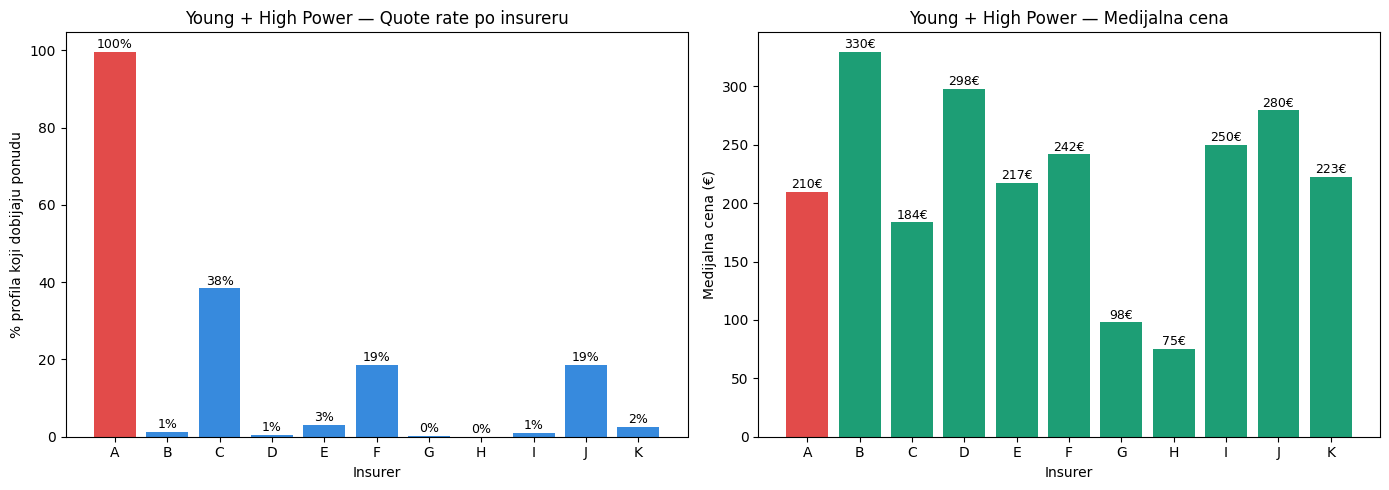

Saved: young_highpower_analysis.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

insurers = []
rates = []
medians = []

for pc in price_cols:
    ins = pc.replace("Insurer_","").replace("_price","")
    rate = sub[pc].notna().mean() * 100
    med  = sub[pc].median()
    insurers.append(ins)
    rates.append(rate)
    medians.append(med if pd.notna(med) else 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Quote rate
colors = ["#E24B4A" if r == max(rates) else "#378ADD" for r in rates]
ax1.bar(insurers, rates, color=colors)
ax1.set_title("Young + High Power — Quote rate po insureru")
ax1.set_ylabel("% profila koji dobijaju ponudu")
ax1.set_xlabel("Insurer")
for i, v in enumerate(rates):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)

# Grafik 2: Medijalna cena (samo za one koji kvotuju)
colors2 = ["#E24B4A" if r == max(rates) else "#1D9E75" for r in rates]
ax2.bar(insurers, medians, color=colors2)
ax2.set_title("Young + High Power — Medijalna cena")
ax2.set_ylabel("Medijalna cena (€)")
ax2.set_xlabel("Insurer")
for i, v in enumerate(medians):
    if v > 0:
        ax2.text(i, v + 3, f"{v:.0f}€", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("young_highpower_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: young_highpower_analysis.png")

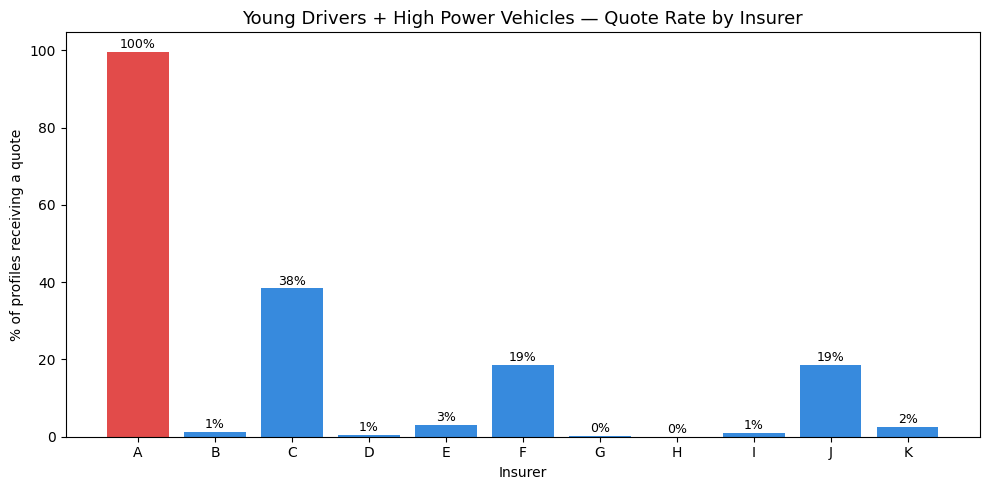

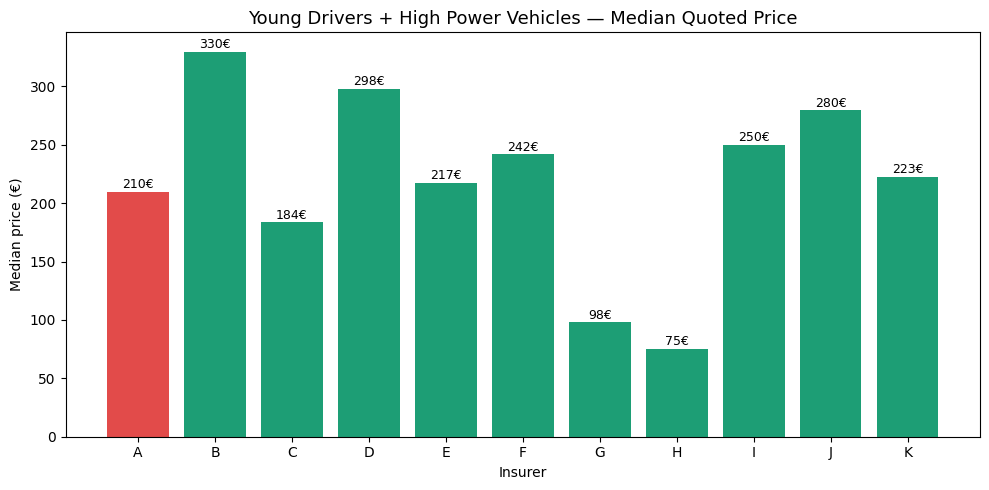

Saved: quote_rate_young_highpower.png
Saved: median_price_young_highpower.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

insurers = []
rates = []
medians = []

for pc in price_cols:
    ins = pc.replace("Insurer_","").replace("_price","")
    rate = sub[pc].notna().mean() * 100
    med  = sub[pc].median()
    insurers.append(ins)
    rates.append(rate)
    medians.append(med if pd.notna(med) else 0)

# Slika 1: Quote rate
fig1, ax1 = plt.subplots(figsize=(10, 5))
colors1 = ["#E24B4A" if r == max(rates) else "#378ADD" for r in rates]
ax1.bar(insurers, rates, color=colors1)
ax1.set_title("Young Drivers + High Power Vehicles — Quote Rate by Insurer", fontsize=13)
ax1.set_ylabel("% of profiles receiving a quote")
ax1.set_xlabel("Insurer")
for i, v in enumerate(rates):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("quote_rate_young_highpower.png", dpi=150, bbox_inches="tight")
plt.show()

# Slika 2: Medijalna cena
fig2, ax2 = plt.subplots(figsize=(10, 5))
colors2 = ["#E24B4A" if r == max(rates) else "#1D9E75" for r in rates]
ax2.bar(insurers, medians, color=colors2)
ax2.set_title("Young Drivers + High Power Vehicles — Median Quoted Price", fontsize=13)
ax2.set_ylabel("Median price (€)")
ax2.set_xlabel("Insurer")
for i, v in enumerate(medians):
    if v > 0:
        ax2.text(i, v + 3, f"{v:.0f}€", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("median_price_young_highpower.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: quote_rate_young_highpower.png")
print("Saved: median_price_young_highpower.png")

Number of profiles: 859


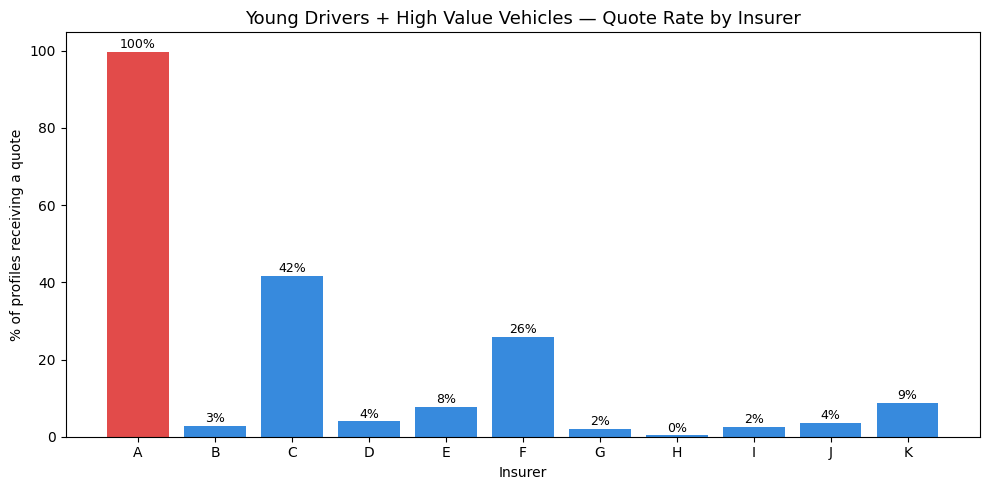

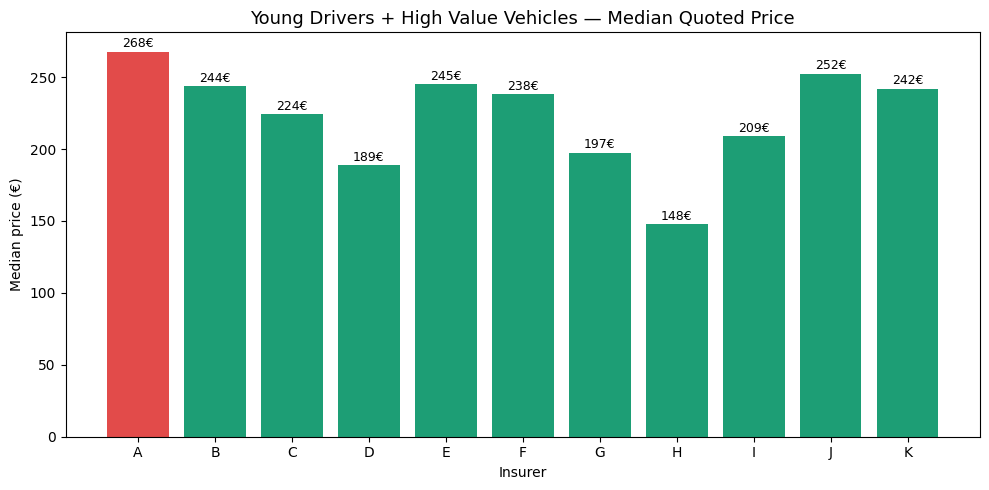

Saved: quote_rate_young_highvalue.png
Saved: median_price_young_highvalue.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Filtriraj young + high value
df["vehicle_value_new"] = pd.to_numeric(df["vehicle_value_new"], errors="coerce")
mask2 = (df["driver_age"] < 25) & (df["vehicle_value_new"] > 100000)
sub2 = df[mask2]

print(f"Number of profiles: {len(sub2)}")

insurers = []
rates = []
medians = []

for pc in price_cols:
    ins = pc.replace("Insurer_","").replace("_price","")
    rate = sub2[pc].notna().mean() * 100
    med  = sub2[pc].median()
    insurers.append(ins)
    rates.append(rate)
    medians.append(med if pd.notna(med) else 0)

# Plot 1: Quote rate
fig1, ax1 = plt.subplots(figsize=(10, 5))
colors1 = ["#E24B4A" if r == max(rates) else "#378ADD" for r in rates]
ax1.bar(insurers, rates, color=colors1)
ax1.set_title("Young Drivers + High Value Vehicles — Quote Rate by Insurer", fontsize=13)
ax1.set_ylabel("% of profiles receiving a quote")
ax1.set_xlabel("Insurer")
for i, v in enumerate(rates):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("quote_rate_young_highvalue.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Median price
fig2, ax2 = plt.subplots(figsize=(10, 5))
colors2 = ["#E24B4A" if r == max(rates) else "#1D9E75" for r in rates]
ax2.bar(insurers, medians, color=colors2)
ax2.set_title("Young Drivers + High Value Vehicles — Median Quoted Price", fontsize=13)
ax2.set_ylabel("Median price (€)")
ax2.set_xlabel("Insurer")
for i, v in enumerate(medians):
    if v > 0:
        ax2.text(i, v + 3, f"{v:.0f}€", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("median_price_young_highvalue.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: quote_rate_young_highvalue.png")
print("Saved: median_price_young_highvalue.png")


In [14]:
import pandas as pd
import numpy as np

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["market_avg"] = df[price_cols].mean(axis=1)

loc_cols = [c for c in df.columns if c.startswith("postal_code_")]
for c in loc_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Korelacija svih location featuresa sa prosecnom cenom
corrs = {}
for col in loc_cols:
    mask = df[col].notna() & df["market_avg"].notna()
    if mask.sum() > 100:
        corrs[col] = df.loc[mask, [col, "market_avg"]].corr().iloc[0,1]

corrs_sorted = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)

print("Top 15 location features by correlation with price:")
for k, v in corrs_sorted[:15]:
    print(f"  {k:<55} {v:+.3f}")

print("\nBottom 5 (weakest):")
for k, v in corrs_sorted[-5:]:
    print(f"  {k:<55} {v:+.3f}")

Top 15 location features by correlation with price:
  postal_code_department_stores_within_10_km              +0.134
  postal_code_primary_schools_within_3_km                 +0.122
  postal_code_hospitals_excl_clinic_within_10_km          +0.121
  postal_code_cinemas_within_10_km                        +0.118
  postal_code_museums_within_10_km                        +0.118
  postal_code_daycares_within_3_km                        +0.118
  postal_code_hospitals_incl_clinic_within_10_km          +0.117
  postal_code_supermarkets_within_3_km                    +0.116
  postal_code_secondary_schools_vmbo_within_5_km          +0.116
  postal_code_secondary_schools_within_5_km               +0.116
  postal_code_after_school_cares_within_3_km              +0.116
  postal_code_performance_venues_within_10_km             +0.113
  postal_code_urban_category                              -0.110
  postal_code_general_practitioners_within_3_km           +0.110
  postal_code_groceries_within_3_km   

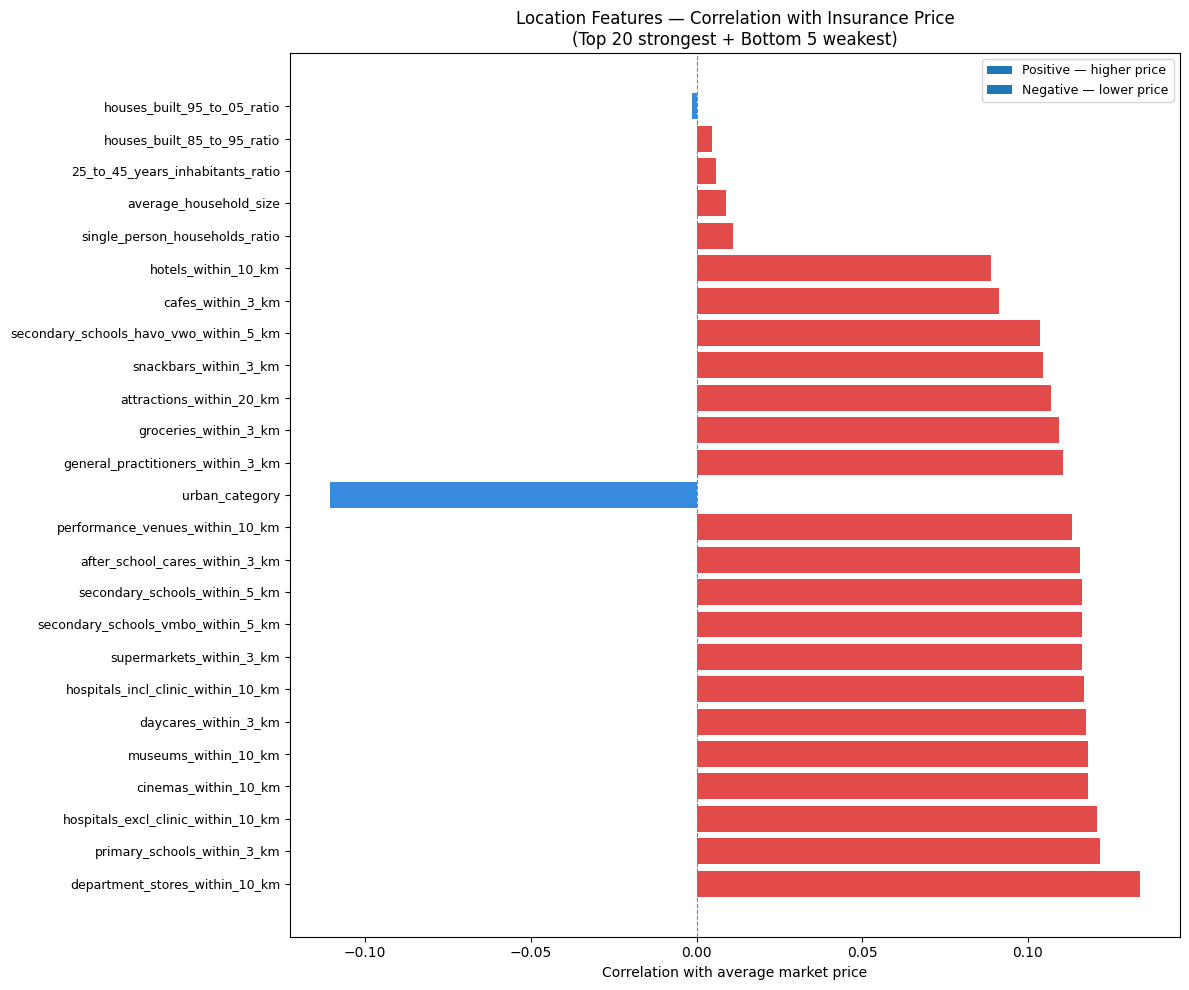

Saved: location_correlation.png


In [15]:
import matplotlib.pyplot as plt

# Top 20 i bottom 5
top20 = corrs_sorted[:20]
bot5  = corrs_sorted[-5:]
to_plot = top20 + bot5

features = [k.replace("postal_code_", "") for k, v in to_plot]
values   = [v for k, v in to_plot]

colors = ["#E24B4A" if v > 0 else "#378ADD" for v in values]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(features)), values, color=colors, edgecolor="none")
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=9)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Correlation with average market price")
ax.set_title("Location Features — Correlation with Insurance Price\n(Top 20 strongest + Bottom 5 weakest)", fontsize=12)

# Legenda
ax.barh([], [], color="#E24B4A", label="Positive — higher price")
ax.barh([], [], color="#378ADD", label="Negative — lower price")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("location_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: location_correlation.png")

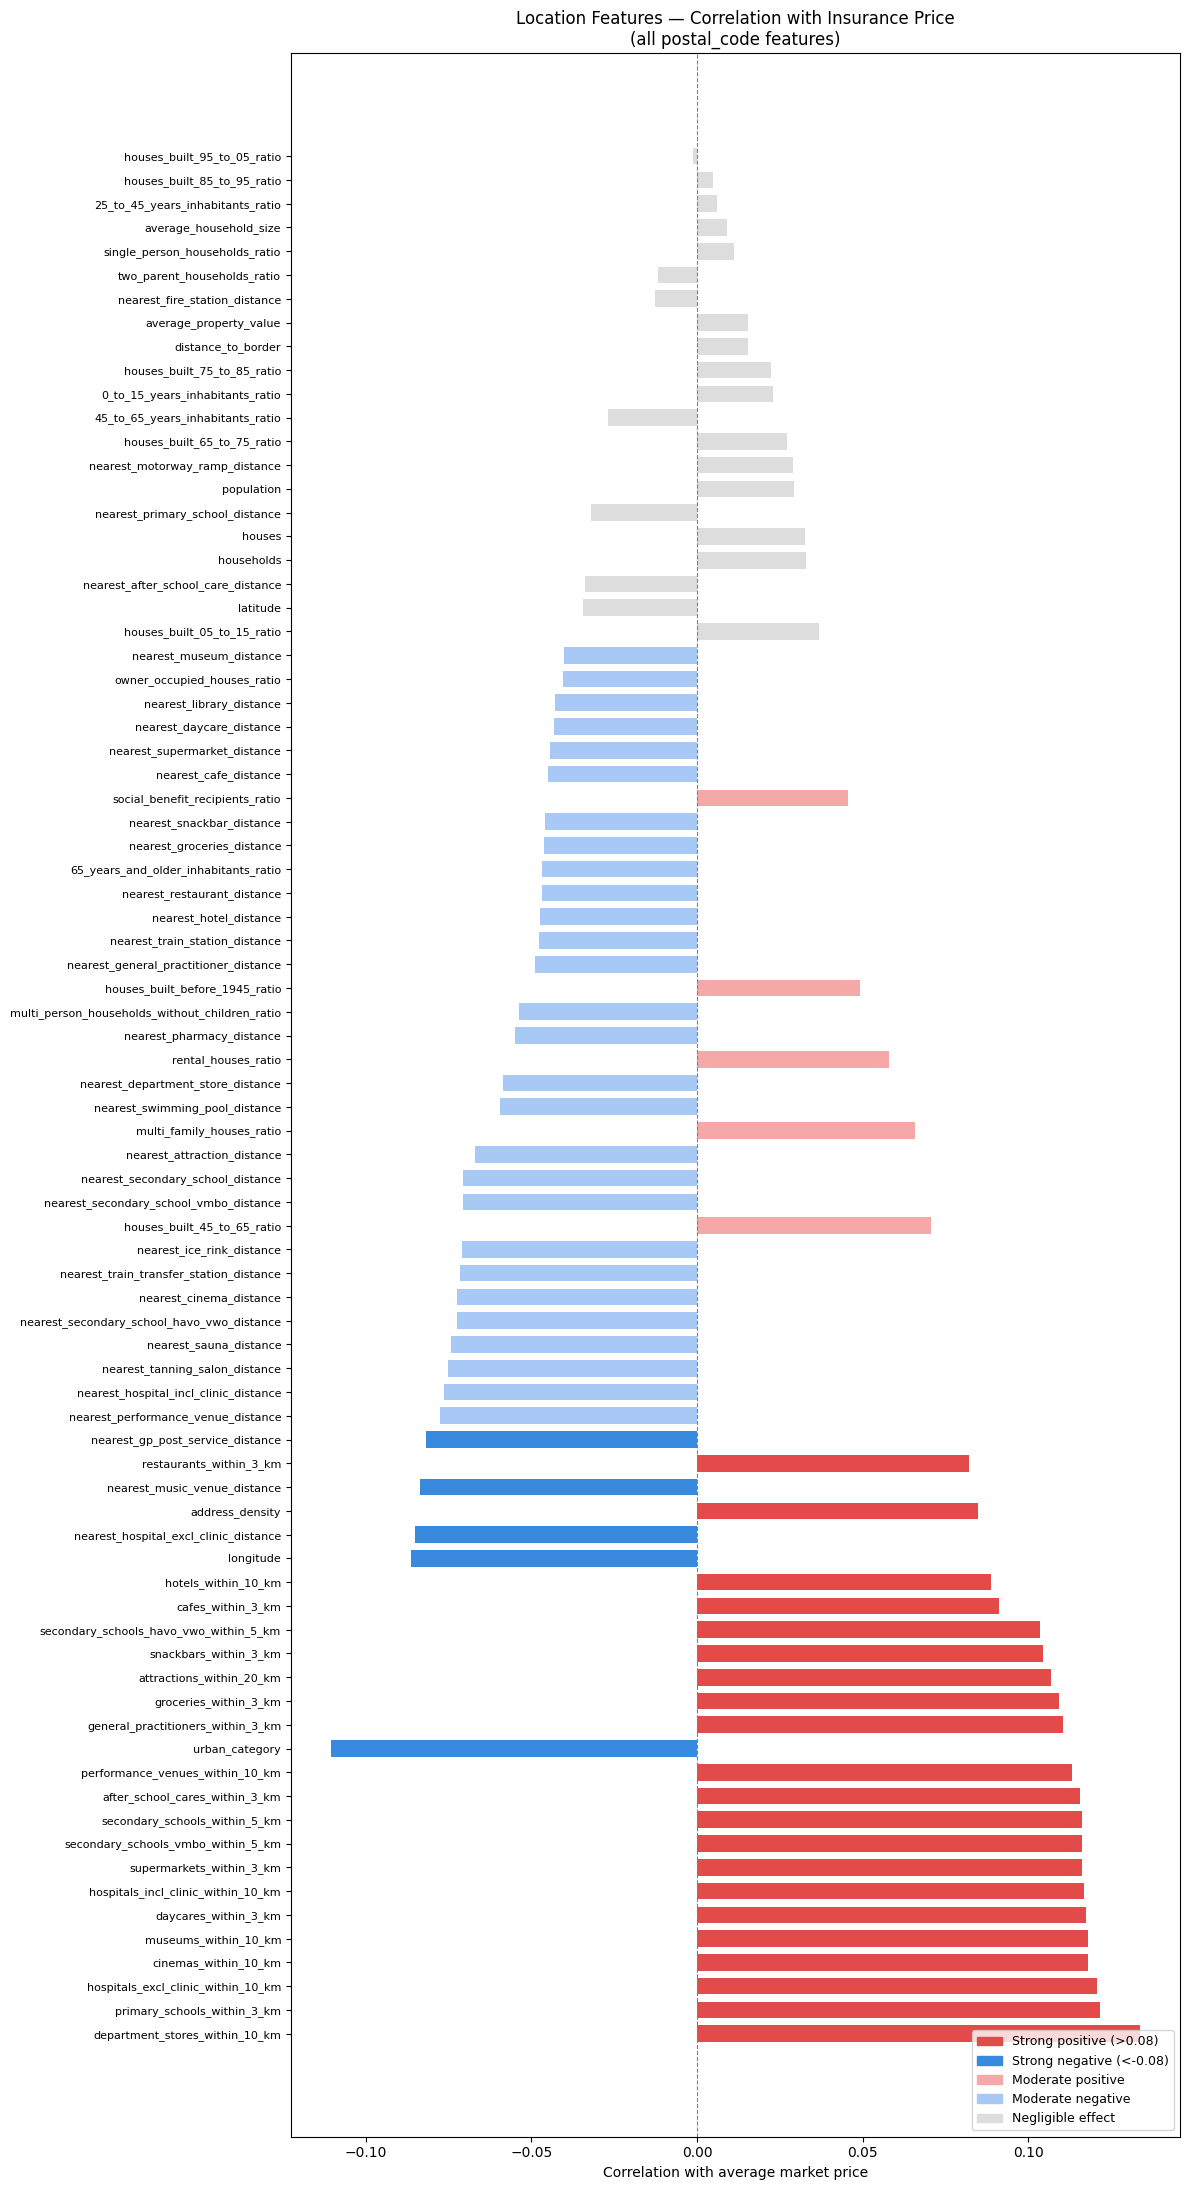

Saved: location_correlation_all.png


In [16]:
import matplotlib.pyplot as plt

# Svi location features, sortirani po apsolutnoj korelaciji
all_sorted = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)

features = [k.replace("postal_code_", "") for k, v in all_sorted]
values   = [v for k, v in all_sorted]

# Boje: jako utiče = zasićeno, slabo = bledo
colors = []
for v in values:
    if abs(v) > 0.08:
        colors.append("#E24B4A" if v > 0 else "#378ADD")  # jako — crveno/plavo
    elif abs(v) > 0.04:
        colors.append("#F5A8A8" if v > 0 else "#A8C8F5")  # srednje — bledo
    else:
        colors.append("#DDDDDD")  # zanemarljivo — sivo

fig, ax = plt.subplots(figsize=(12, 22))
bars = ax.barh(range(len(features)), values, color=colors, edgecolor="none", height=0.7)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=8)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Correlation with average market price")
ax.set_title("Location Features — Correlation with Insurance Price\n(all postal_code features)", fontsize=12)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(color="#E24B4A", label="Strong positive (>0.08)"),
    Patch(color="#378ADD", label="Strong negative (<-0.08)"),
    Patch(color="#F5A8A8", label="Moderate positive"),
    Patch(color="#A8C8F5", label="Moderate negative"),
    Patch(color="#DDDDDD", label="Negligible effect"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("location_correlation_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: location_correlation_all.png")

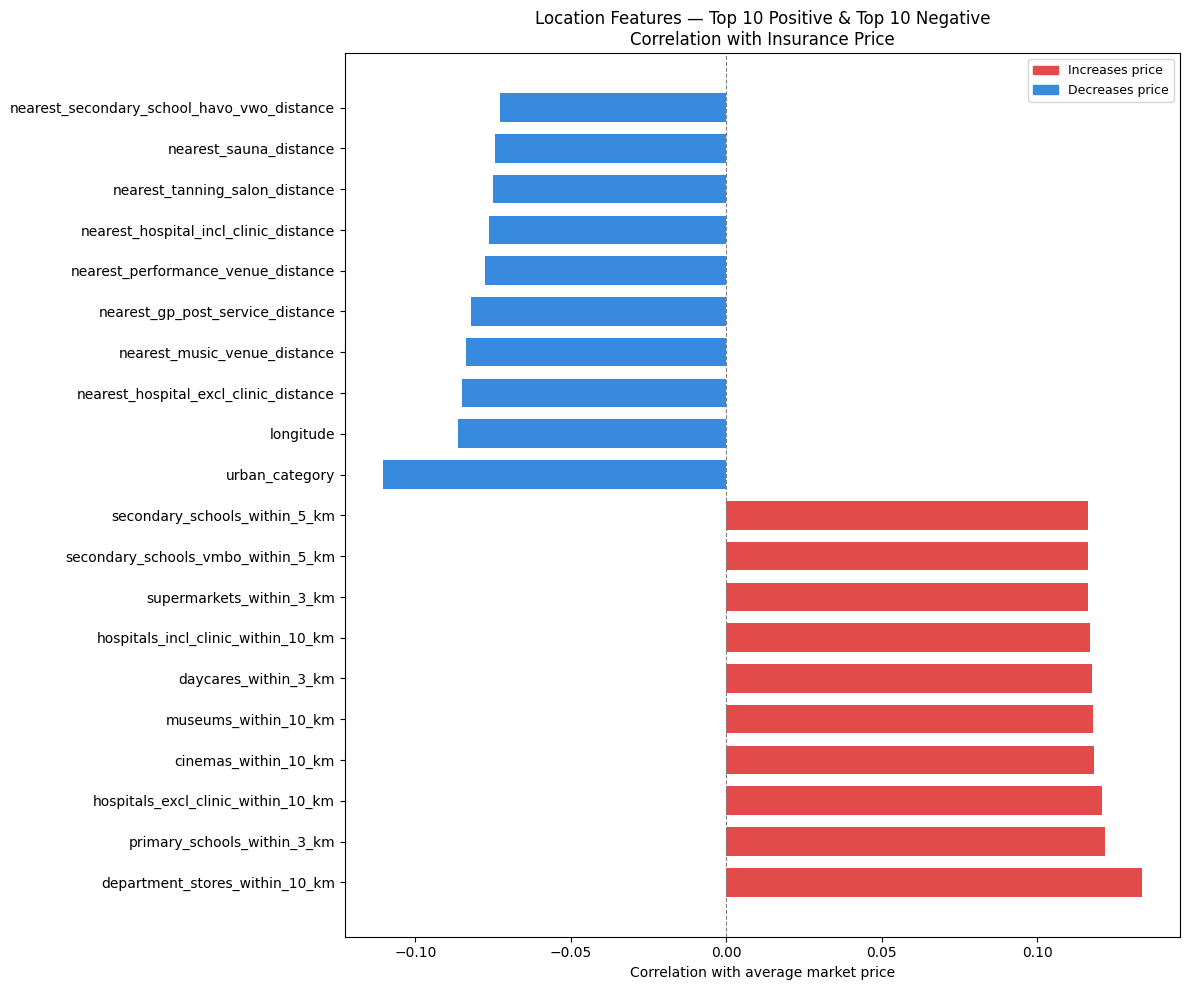

Saved: location_correlation_top.png


In [18]:

import matplotlib.pyplot as plt

# Top 10 pozitivnih + top 10 negativnih
top_pos = sorted(corrs.items(), key=lambda x: x[1], reverse=True)[:10]
top_neg = sorted(corrs.items(), key=lambda x: x[1])[:10]

to_plot  = top_pos + top_neg
features = [k.replace("postal_code_", "") for k, v in to_plot]
values   = [v for k, v in to_plot]
colors   = ["#E24B4A" if v > 0 else "#378ADD" for v in values]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(features)), values, color=colors, edgecolor="none", height=0.7)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=10)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Correlation with average market price")
ax.set_title("Location Features — Top 10 Positive & Top 10 Negative\nCorrelation with Insurance Price", fontsize=12)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#E24B4A", label="Increases price"),
    Patch(color="#378ADD", label="Decreases price"),
], fontsize=9)

plt.tight_layout()
plt.savefig("location_correlation_top.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: location_correlation_top.png")

Oldtimers (>30y): 1368
Regular (3-10y):          498218
Coverage split oldtimers: {'mtpl': 1.0}


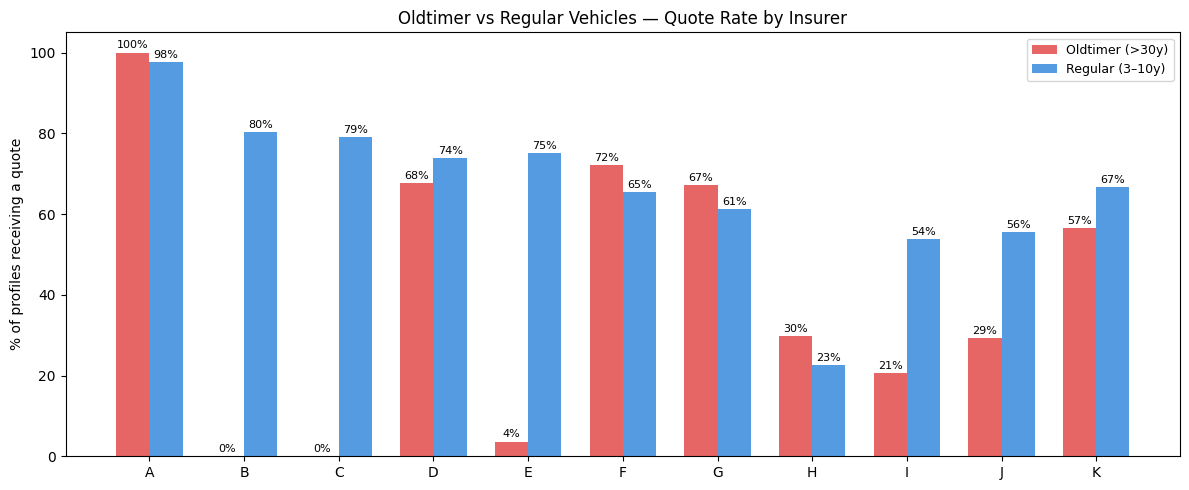

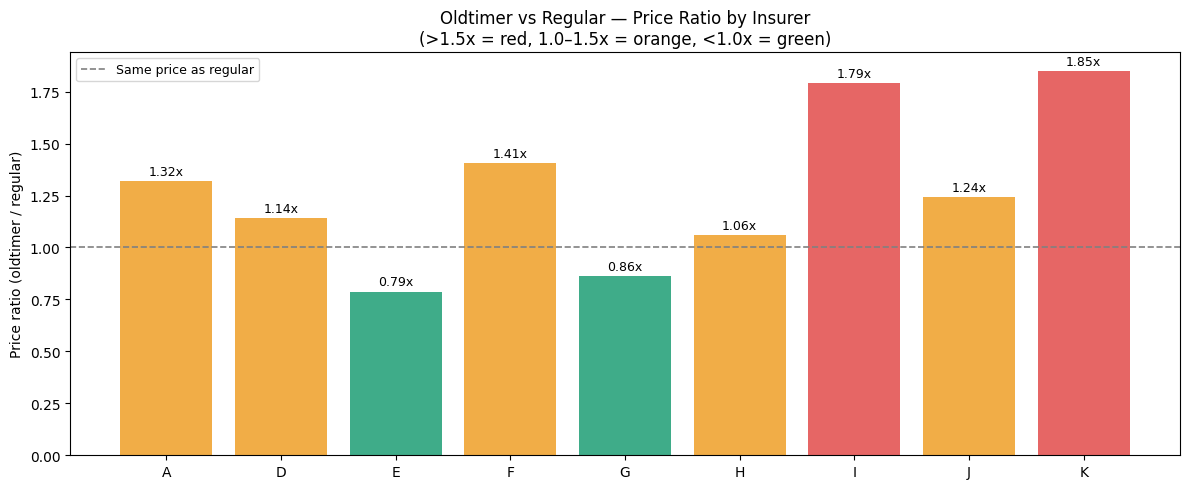

Saved: oldtimer_quote_rate.png
Saved: oldtimer_price_ratio.png


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["vehicle_age"]       = pd.to_numeric(df["vehicle_age"],       errors="coerce")
df["vehicle_value_new"] = pd.to_numeric(df["vehicle_value_new"], errors="coerce")
df["claim_free_years"]  = pd.to_numeric(df["claim_free_years"],  errors="coerce")

OLDTIMER_THRESHOLD = 30

oldtimers = df[df["vehicle_age"] > OLDTIMER_THRESHOLD]
regular   = df[(df["vehicle_age"] >= 3) & (df["vehicle_age"] <= 30)]

print(f"Oldtimers (>{OLDTIMER_THRESHOLD}y): {len(oldtimers)}")
print(f"Regular (3-10y):          {len(regular)}")
print(f"Coverage split oldtimers: {oldtimers['coverage'].value_counts(normalize=True).round(2).to_dict()}")

insurers  = []
rates_old = []
rates_reg = []
price_old = []
price_reg = []

for pc in price_cols:
    ins = pc.replace("Insurer_","").replace("_price","")
    insurers.append(ins)
    rates_old.append(oldtimers[pc].notna().mean() * 100)
    rates_reg.append(regular[pc].notna().mean()   * 100)
    price_old.append(oldtimers[pc].median())
    price_reg.append(regular[pc].median())

# ── Plot 1: Quote rate ────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 5))
x = np.arange(len(insurers))
w = 0.35
ax1.bar(x - w/2, rates_old, w, label=f"Oldtimer (>{OLDTIMER_THRESHOLD}y)", color="#E24B4A", alpha=0.85)
ax1.bar(x + w/2, rates_reg, w, label="Regular (3–10y)",                    color="#378ADD", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(insurers)
ax1.set_ylabel("% of profiles receiving a quote")
ax1.set_title(f"Oldtimer vs Regular Vehicles — Quote Rate by Insurer", fontsize=12)
ax1.legend(fontsize=9)
for i in range(len(insurers)):
    ax1.text(i - w/2, rates_old[i] + 1, f"{rates_old[i]:.0f}%", ha="center", fontsize=8)
    ax1.text(i + w/2, rates_reg[i] + 1, f"{rates_reg[i]:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("oldtimer_quote_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Median price ratio ────────────────────────────────────────────────
ratios = []
valid_ins = []
for i, ins in enumerate(insurers):
    if pd.notna(price_old[i]) and pd.notna(price_reg[i]) and price_reg[i] > 0:
        ratios.append(price_old[i] / price_reg[i])
        valid_ins.append(ins)

fig2, ax2 = plt.subplots(figsize=(12, 5))
colors = ["#E24B4A" if r > 1.5 else "#EF9F27" if r > 1.0 else "#1D9E75" for r in ratios]
ax2.bar(valid_ins, ratios, color=colors, alpha=0.85)
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1.2, label="Same price as regular")
ax2.set_ylabel("Price ratio (oldtimer / regular)")
ax2.set_title("Oldtimer vs Regular — Price Ratio by Insurer\n(>1.5x = red, 1.0–1.5x = orange, <1.0x = green)", fontsize=12)
ax2.legend(fontsize=9)
for i, (ins, r) in enumerate(zip(valid_ins, ratios)):
    ax2.text(i, r + 0.03, f"{r:.2f}x", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("oldtimer_price_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: oldtimer_quote_rate.png")
print("Saved: oldtimer_price_ratio.png")

Oldtimers (age>20 + value>25k): 663
Regular (age 3-10, value 10-40k): 336833
Coverage split oldtimers: {'mtpl': 1.0}


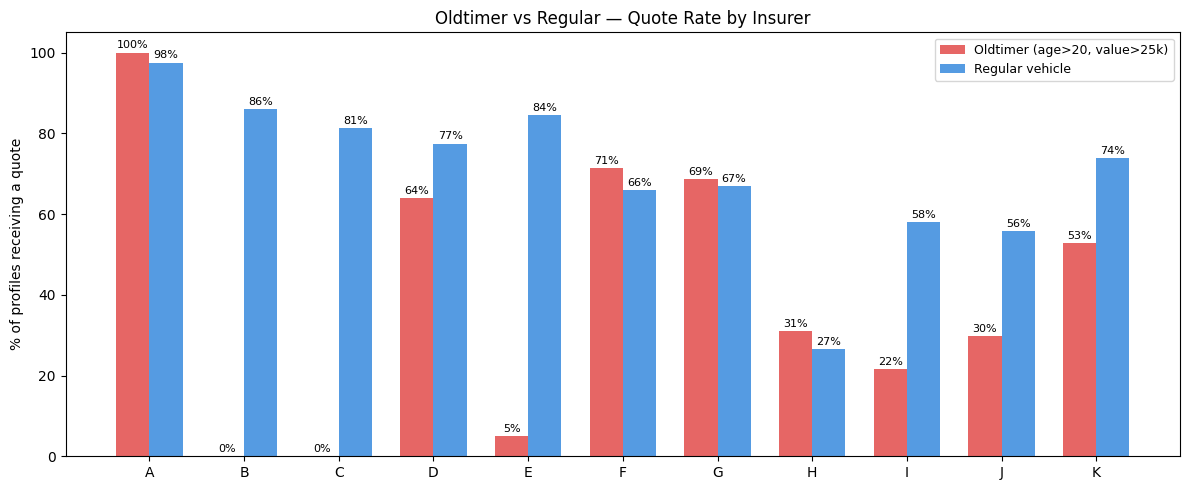

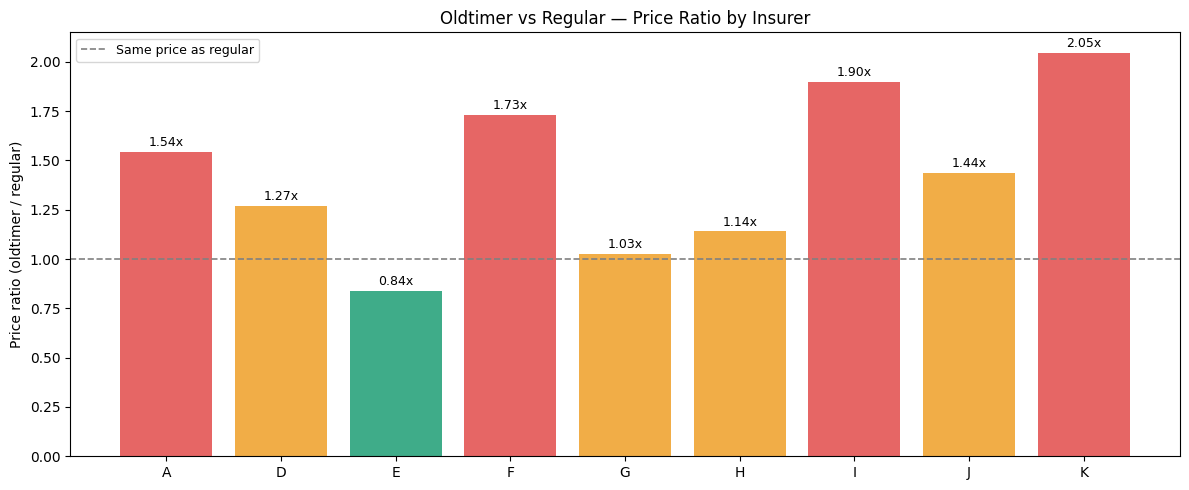

Saved: oldtimer_quote_rate.png
Saved: oldtimer_price_ratio.png


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["vehicle_age"]       = pd.to_numeric(df["vehicle_age"],       errors="coerce")
df["vehicle_value_new"] = pd.to_numeric(df["vehicle_value_new"], errors="coerce")

# Prava definicija oldtimera: staro I skupo
oldtimers = df[(df["vehicle_age"] > 30) & (df["vehicle_value_new"] > 25000)]
regular   = df[(df["vehicle_age"] >= 3) & (df["vehicle_age"] <= 30)
              & (df["vehicle_value_new"] > 10000) & (df["vehicle_value_new"] < 40000)]

print(f"Oldtimers (age>20 + value>25k): {len(oldtimers)}")
print(f"Regular (age 3-10, value 10-40k): {len(regular)}")
print(f"Coverage split oldtimers: {oldtimers['coverage'].value_counts(normalize=True).round(2).to_dict()}")

insurers  = []
rates_old = []
rates_reg = []
price_old = []
price_reg = []

for pc in price_cols:
    ins = pc.replace("Insurer_","").replace("_price","")
    insurers.append(ins)
    rates_old.append(oldtimers[pc].notna().mean() * 100)
    rates_reg.append(regular[pc].notna().mean()   * 100)
    price_old.append(oldtimers[pc].median())
    price_reg.append(regular[pc].median())

# Plot 1: Quote rate
fig1, ax1 = plt.subplots(figsize=(12, 5))
x = np.arange(len(insurers))
w = 0.35
ax1.bar(x - w/2, rates_old, w, label="Oldtimer (age>20, value>25k)", color="#E24B4A", alpha=0.85)
ax1.bar(x + w/2, rates_reg, w, label="Regular vehicle",              color="#378ADD", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(insurers)
ax1.set_ylabel("% of profiles receiving a quote")
ax1.set_title("Oldtimer vs Regular — Quote Rate by Insurer", fontsize=12)
ax1.legend(fontsize=9)
for i in range(len(insurers)):
    ax1.text(i - w/2, rates_old[i] + 1, f"{rates_old[i]:.0f}%", ha="center", fontsize=8)
    ax1.text(i + w/2, rates_reg[i] + 1, f"{rates_reg[i]:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("oldtimer_quote_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Price ratio
ratios    = []
valid_ins = []
for i, ins in enumerate(insurers):
    if pd.notna(price_old[i]) and pd.notna(price_reg[i]) and price_reg[i] > 0:
        ratios.append(price_old[i] / price_reg[i])
        valid_ins.append(ins)

fig2, ax2 = plt.subplots(figsize=(12, 5))
colors = ["#E24B4A" if r > 1.5 else "#EF9F27" if r > 1.0 else "#1D9E75" for r in ratios]
ax2.bar(valid_ins, ratios, color=colors, alpha=0.85)
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1.2, label="Same price as regular")
ax2.set_ylabel("Price ratio (oldtimer / regular)")
ax2.set_title("Oldtimer vs Regular — Price Ratio by Insurer", fontsize=12)
ax2.legend(fontsize=9)
for i, (ins, r) in enumerate(zip(valid_ins, ratios)):
    ax2.text(i, r + 0.03, f"{r:.2f}x", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("oldtimer_price_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: oldtimer_quote_rate.png")
print("Saved: oldtimer_price_ratio.png")

In [23]:
import pandas as pd

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Payment frequency distribution:")
print(df["payment_frequency"].value_counts())
print()

yearly = df[df["payment_frequency"] == "yearly"]
print(f"Yearly profiles: {len(yearly)}")
print()

print("Quote rate for YEARLY payment:")
for pc in price_cols:
    ins = pc.replace("Insurer_","").replace("_price","")
    rate = yearly[pc].notna().mean() * 100
    med  = yearly[pc].median()
    print(f"  {ins}: {rate:.0f}%  median={med:.0f}€" if pd.notna(med) else f"  {ins}: {rate:.0f}%  median=N/A")

Payment frequency distribution:
payment_frequency
monthly    529806
yearly      11486
Name: count, dtype: int64

Yearly profiles: 11486

Quote rate for YEARLY payment:
  A: 85%  median=558€
  B: 0%  median=N/A
  C: 0%  median=N/A
  D: 0%  median=N/A
  E: 0%  median=N/A
  F: 0%  median=N/A
  G: 0%  median=N/A
  H: 0%  median=N/A
  I: 0%  median=N/A
  J: 0%  median=N/A
  K: 0%  median=N/A


In [24]:
import pandas as pd
import numpy as np

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

yearly  = df[df["payment_frequency"] == "yearly"]
monthly = df[df["payment_frequency"] == "monthly"]

print(f"Yearly:  {len(yearly)} profila")
print(f"Monthly: {len(monthly)} profila")
print()

print(f"{'Insurer':<12} {'Monthly med':>12} {'Yearly med':>12} {'Diff':>10} {'Yearly cheaper?':>16}")
print("-" * 55)
for pc in price_cols:
    ins  = pc.replace("Insurer_","").replace("_price","")
    m_med = monthly[pc].median()
    y_med = yearly[pc].median()
    if pd.notna(m_med) and pd.notna(y_med):
        diff = y_med - m_med
        cheaper = "YES" if diff < 0 else "NO"
        print(f"  {ins:<10} {m_med:>11.1f}€ {y_med:>11.1f}€ {diff:>+9.1f}€ {cheaper:>16}")
    else:
        print(f"  {ins:<10} {m_med if pd.notna(m_med) else 'N/A':>12} {'N/A':>12}")

Yearly:  11486 profila
Monthly: 529806 profila

Insurer       Monthly med   Yearly med       Diff  Yearly cheaper?
-------------------------------------------------------
  A                 66.8€       558.2€    +491.4€               NO
  B                 76.34          N/A
  C                 70.84          N/A
  D                 75.83          N/A
  E                 90.29          N/A
  F                 79.13          N/A
  G                 70.35          N/A
  H                 92.44          N/A
  I                 70.01          N/A
  J                  82.2          N/A
  K                 97.14          N/A


In [26]:

import pandas as pd
import numpy as np

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["market_avg"] = df[price_cols].mean(axis=1)

print("Top 20 most common makers:")
print(df["vehicle_maker"].value_counts().head(20))
print()

# Median market price per maker (min 50 profiles)
maker_stats = df.groupby("vehicle_maker").agg(
    n          = ("market_avg", "count"),
    median_price = ("market_avg", "median"),
    mean_price   = ("market_avg", "mean"),
).round(1)

maker_stats = maker_stats[maker_stats["n"] >= 50].sort_values("median_price", ascending=False)

print("Median market price by maker (min 50 profiles):")
print(maker_stats)


Top 20 most common makers:
vehicle_maker
volkswagen       78101
bmw              39170
peugeot          34758
toyota           34316
audi             32104
ford             30355
opel             28813
renault          25568
mercedes-benz    23717
kia              23037
volvo            20419
seat             17298
citroen          16573
hyundai          16070
fiat             14310
skoda            12544
suzuki           12475
nissan           10270
mazda             9752
tesla             8734
Name: count, dtype: int64

Median market price by maker (min 50 profiles):
                       n  median_price  mean_price
vehicle_maker                                     
xpeng                150         161.8       235.6
polestar            1284         153.7       206.1
cupra               2210         142.4       176.1
tesla               8711         140.7       187.4
mercedes-amg         105         135.7       160.0
tesla motors         672         134.0       154.7
maserati        

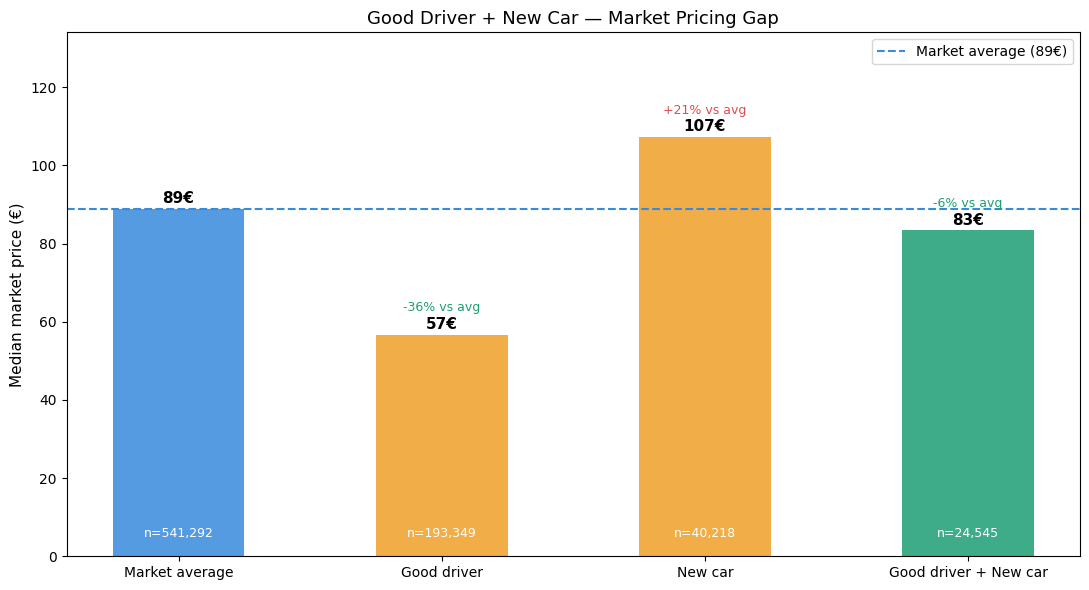

Saved: good_driver_new_car.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["claim_free_years"] = pd.to_numeric(df["claim_free_years"], errors="coerce")
df["vehicle_age"]      = pd.to_numeric(df["vehicle_age"],      errors="coerce")

df["market_avg"] = df[price_cols].mean(axis=1)

# Segmenti
good_driver = df["claim_free_years"] > 5
new_car     = df["vehicle_age"] < 3

segments = {
    "Market average":          df,
    "Good driver":             df[good_driver],
    "New car":                 df[new_car],
    "Good driver + New car":   df[good_driver & new_car],
}

labels  = list(segments.keys())
medians = [seg["market_avg"].median() for seg in segments.values()]
counts  = [len(seg) for seg in segments.values()]

market_median = df["market_avg"].median()

fig, ax = plt.subplots(figsize=(11, 6))

colors = ["#378ADD" if l == "Market average" else
          "#1D9E75" if l == "Good driver + New car" else
          "#EF9F27" for l in labels]

bars = ax.bar(labels, medians, color=colors, alpha=0.85, width=0.5)

# Referentna linija — market average
ax.axhline(market_median, color="#378ADD", linestyle="--", linewidth=1.5, label=f"Market average ({market_median:.0f}€)")

# Labele na barovima
for bar, med, n in zip(bars, medians, counts):
    ax.text(bar.get_x() + bar.get_width()/2, med + 1.5,
            f"{med:.0f}€", ha="center", fontsize=11, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, 5,
            f"n={n:,}", ha="center", fontsize=9, color="white")

# % vs market average
for bar, med in zip(bars, medians):
    pct = (med / market_median - 1) * 100
    if abs(pct) > 1:
        ax.text(bar.get_x() + bar.get_width()/2, med + 6,
                f"{pct:+.0f}% vs avg", ha="center", fontsize=9,
                color="#E24B4A" if pct > 0 else "#1D9E75")

ax.set_ylabel("Median market price (€)", fontsize=11)
ax.set_title("Good Driver + New Car — Market Pricing Gap", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, max(medians) * 1.25)

plt.tight_layout()
plt.savefig("good_driver_new_car.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: good_driver_new_car.png")

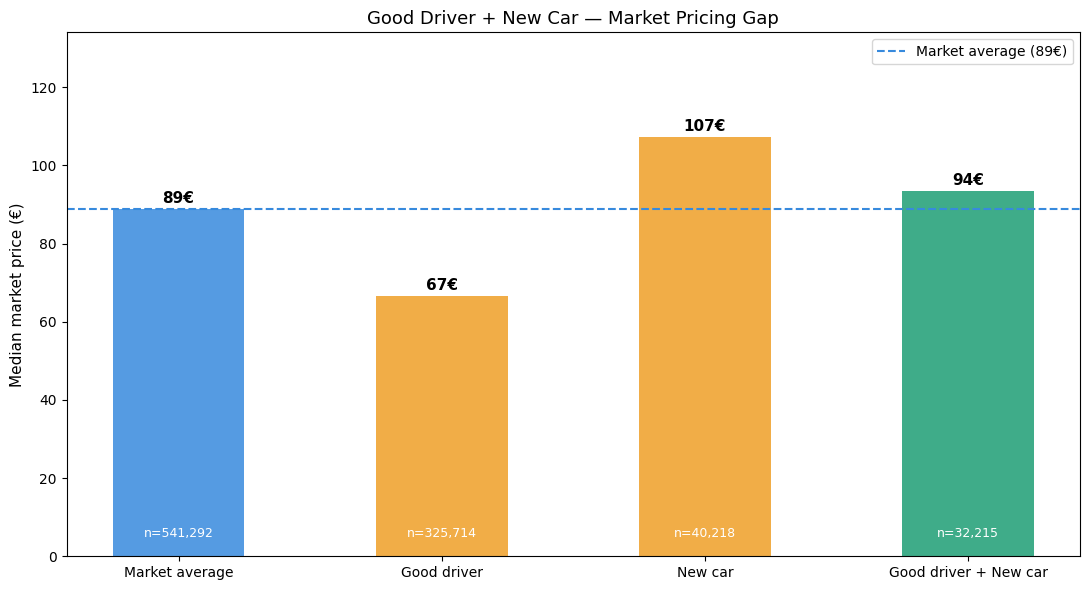

Saved: good_driver_new_car.png


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["claim_free_years"] = pd.to_numeric(df["claim_free_years"], errors="coerce")
df["vehicle_age"]      = pd.to_numeric(df["vehicle_age"],      errors="coerce")

df["market_avg"] = df[price_cols].mean(axis=1)

# Segmenti
good_driver = df["claim_free_years"] > 1
new_car     = df["vehicle_age"] < 3

segments = {
    "Market average":          df,
    "Good driver":             df[good_driver],
    "New car":                 df[new_car],
    "Good driver + New car":   df[good_driver & new_car],
}

labels  = list(segments.keys())
medians = [seg["market_avg"].median() for seg in segments.values()]
counts  = [len(seg) for seg in segments.values()]

market_median = df["market_avg"].median()

fig, ax = plt.subplots(figsize=(11, 6))

colors = ["#378ADD" if l == "Market average" else
          "#1D9E75" if l == "Good driver + New car" else
          "#EF9F27" for l in labels]

bars = ax.bar(labels, medians, color=colors, alpha=0.85, width=0.5)

# Referentna linija — market average
ax.axhline(market_median, color="#378ADD", linestyle="--", linewidth=1.5, label=f"Market average ({market_median:.0f}€)")

# Labele na barovima
for bar, med, n in zip(bars, medians, counts):
    ax.text(bar.get_x() + bar.get_width()/2, med + 1.5,
            f"{med:.0f}€", ha="center", fontsize=11, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, 5,
            f"n={n:,}", ha="center", fontsize=9, color="white")


ax.set_ylabel("Median market price (€)", fontsize=11)
ax.set_title("Good Driver + New Car — Market Pricing Gap", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, max(medians) * 1.25)

plt.tight_layout()
plt.savefig("good_driver_new_car.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: good_driver_new_car.png")

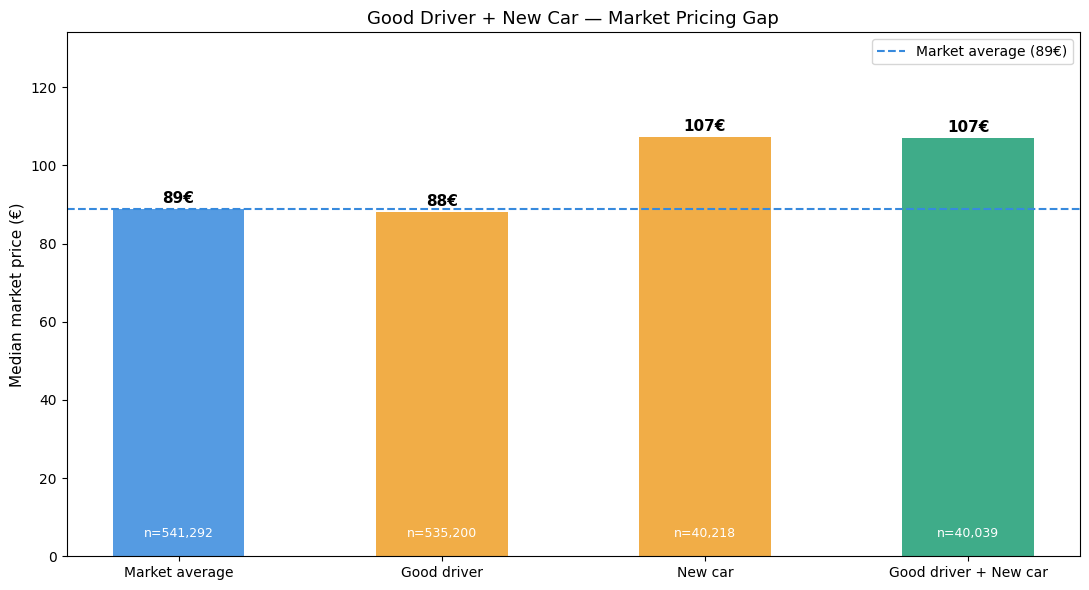

Saved: good_driver_new_car.png


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("block1_train.parquet")

price_cols = [c for c in df.columns if c.endswith("_price")]
for c in price_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["claim_free_years"] = pd.to_numeric(df["claim_free_years"], errors="coerce")
df["vehicle_age"]      = pd.to_numeric(df["vehicle_age"],      errors="coerce")

df["market_avg"] = df[price_cols].mean(axis=1)

# Segmenti
good_driver = df["claim_free_years"] > -1
new_car     = df["vehicle_age"] < 3

segments = {
    "Market average":          df,
    "Good driver":             df[good_driver],
    "New car":                 df[new_car],
    "Good driver + New car":   df[good_driver & new_car],
}

labels  = list(segments.keys())
medians = [seg["market_avg"].median() for seg in segments.values()]
counts  = [len(seg) for seg in segments.values()]

market_median = df["market_avg"].median()

fig, ax = plt.subplots(figsize=(11, 6))

colors = ["#378ADD" if l == "Market average" else
          "#1D9E75" if l == "Good driver + New car" else
          "#EF9F27" for l in labels]

bars = ax.bar(labels, medians, color=colors, alpha=0.85, width=0.5)

# Referentna linija — market average
ax.axhline(market_median, color="#378ADD", linestyle="--", linewidth=1.5, label=f"Market average ({market_median:.0f}€)")

# Labele na barovima
for bar, med, n in zip(bars, medians, counts):
    ax.text(bar.get_x() + bar.get_width()/2, med + 1.5,
            f"{med:.0f}€", ha="center", fontsize=11, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, 5,
            f"n={n:,}", ha="center", fontsize=9, color="white")


ax.set_ylabel("Median market price (€)", fontsize=11)
ax.set_title("Good Driver + New Car — Market Pricing Gap", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, max(medians) * 1.25)

plt.tight_layout()
plt.savefig("good_driver_new_car.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: good_driver_new_car.png")